In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import math
from huggingface_hub import HfFileSystem, hf_hub_download, snapshot_download
from functools import partial

c:\Users\0dps1\Desktop\CS541-Deep-Learning-Clash-Royale-Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fs = HfFileSystem()
dataset = fs.ls("datasets/chrisrca/clash-royale-tv-replays/arena_18/084c2deb-5b95-44af-9d69-335e3c4d48d5", detail=False)
dataset = [item.split('/')[-1] for item in dataset]
prefix ="arena_18/arena_18/084c2deb-5b95-44af-9d69-335e3c4d48d5/"
dataset = [hf_hub_download(repo_id="chrisrca/clash-royale-tv-replays", filename=f"arena_18/084c2deb-5b95-44af-9d69-335e3c4d48d5/{item}", repo_type="dataset") for item in dataset]
print(dataset[0])



C:\Users\0dps1\.cache\huggingface\hub\datasets--chrisrca--clash-royale-tv-replays\snapshots\dfd520a70e6859ff3dcab9e9ae3aeba83bf4cd76\arena_18\084c2deb-5b95-44af-9d69-335e3c4d48d5\00001.png


(960, 540, 3)


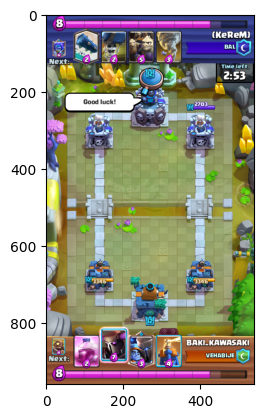

In [3]:
myframe = cv2.imread(dataset[0])
h0, w0 = myframe.shape[:2]
print(myframe.shape)
plt.imshow(myframe)
plt.show()

In [4]:
def get_frame(path):
    return cv2.imread(path)

In [5]:
def remove_border(location):
    return (location[0], location[1])

def rescale(location):
    scale = 854.0 / 389.0
    return (location[0] * scale, location[1] * scale)

def add(a, b):
    return(a[0] + b[0], a[1] + b[1])

def cast(a):
    return(int(a[0]), int(a[1]))

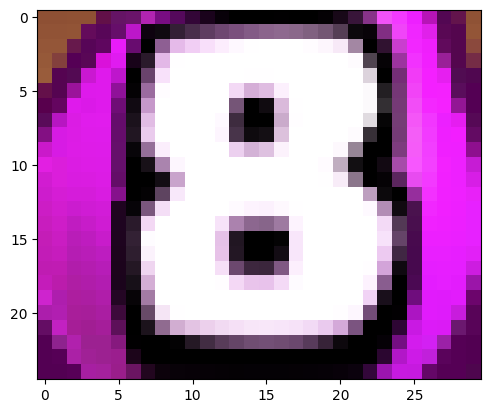

In [6]:
elixir_origin = (103 - 84,823 + 97)
elixir_size = (30,25)
card_origin = (86 - 14, 737 + 97)
card_size = (66,81)
card_space = 5
elixir_bar_origin = (48,839+ 97)
elixir_bar_size = (418+54,3)

def cut_to_fit(image, origin, size):
    x_start = origin[0]
    x_end = x_start + size[0]
    y_start = origin[1]
    y_end = y_start + size[1]
    return image[y_start:y_end,x_start:x_end]


plt.imshow(cut_to_fit(myframe, elixir_origin, elixir_size))
plt.show()

In [7]:
def quantize(frame, levels=4, display=False):
    step_size = 255 // (levels - 1) if display else 1
    quantized = np.clip((frame / 255 * (levels - 1)).astype(int), 0, levels - 1)
    quantized = (quantized * step_size).astype(np.uint8)
    
    return quantized

def downsize(frame, factor):
    return cv2.resize(frame, (frame.shape[1]//factor, frame.shape[0]//factor), interpolation=cv2.INTER_AREA)

def blur(frame, kernel):
    return cv2.GaussianBlur(frame, ksize=kernel, sigmaX=0, sigmaY=0)

def fill_fraction(img, fraction, intensity=127):
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    radius = int(np.hypot(cx, cy))

    steps = max(10, int(100 * fraction))
    angles = np.linspace(-math.pi/2, -math.pi/2 - 2*math.pi*fraction, steps)

    # Create a blank slice mask
    slice_mask = np.zeros_like(img, dtype=np.uint8)

    # Build polygon points
    points = [(cx, cy)] + [
        (int(cx + radius * math.cos(a)), int(cy + radius * math.sin(a)))
        for a in angles
    ]
    pts = np.array(points, np.int32).reshape((-1, 1, 2))

    # Fill the slice with the intensity
    if len(slice_mask.shape) == 3:  # color image
        cv2.fillPoly(slice_mask, [pts], (intensity, intensity, intensity))
    else:  # grayscale
        cv2.fillPoly(slice_mask, [pts], intensity)

    # Add the slice to the original image (with clipping)
    result = cv2.add(img, slice_mask)
    return result

In [8]:
def prep(image, downsize_factor = 4):
    shrunk = downsize(image, 2)
    blurred = blur(shrunk, (3,3))
    compressed = blurred
    return compressed

In [9]:
# cv2.imshow('Video Frame', frame)
def add_not_ready_filter(grayscale_image, elixir_cost, current_elixir):
    overlayed = fill_fraction(grayscale_image, (elixir_cost - current_elixir)/elixir_cost, 127)
    return cv2.cvtColor(overlayed, cv2.COLOR_GRAY2BGR)

frame = get_frame(dataset[14])

def fractional_elixir(frame):
    frame = blur(frame, (3,3))
    elixir_bar = cut_to_fit(frame, elixir_bar_origin, elixir_bar_size)
    target = np.array([132, 71, 78])  # BGR order

    # Define tolerance
    tolerance = 11

    # Compute absolute difference per channel
    diff = np.abs(elixir_bar - target)

    # Mask of pixels within tolerance in all 3 channels
    mask = np.all(diff <= tolerance, axis=-1)

    # Count pixels that match
    count = np.count_nonzero(mask)
    max = 125
    return count/max

print(fractional_elixir(frame))

0.96


In [10]:
def check_exists_add_otherwise(library, newimage, frame, template_threshold, grayscale_threshold, slice_size = 3):
    quantized_grayscaled = cv2.cvtColor(cv2.cvtColor(newimage, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)
    if np.median(np.abs(newimage - quantized_grayscaled)) < grayscale_threshold: # If grayscale version (not ready to play)
        return

    # object: compressed image, original image, view count, timestamp
    shrunk = downsize(newimage, 4)
    blurred = blur(shrunk, (3,3))
    compressed = blurred
    cropped = compressed
    if(slice_size > 0):
        cropped = compressed[slice_size:-slice_size,slice_size:-slice_size]
    if(len(library) == 0):
        library.append([compressed, newimage, 1, frame])
        return
    
    for i, (image, _, _, _) in enumerate(library):
        res = cv2.matchTemplate(image,cropped,cv2.TM_CCOEFF_NORMED)
        _, max_val, _, _ = cv2.minMaxLoc(res)
        if max_val > template_threshold:
            library[i][2]+=1
            return
    library.append([compressed, newimage, 1, frame])

In [11]:
def get_images_in_hand(screenshot):
    hand = []
    for card in range(4):
        card_origin_offset = (card_origin[0] + (card_size[0] + card_space) * card, card_origin[1])
        my_subimage = cut_to_fit(screenshot, card_origin_offset, card_size)
        hand.append(my_subimage)
    return hand

def get_elixir_pic(screenshot):
    my_subimage = cut_to_fit(screenshot, elixir_origin, elixir_size)
    return my_subimage

Use this to find new cards in video

In [12]:
# Go thru video and print all unique segments
def is_persistent(obj, time, override_window = False):
    count = obj[2]
    
    if(override_window):
        return count > 3
    
    age = time - obj[3]

    in_window = 5 < age < 15
    keep = count > 3 or not in_window
    # if not keep:
    #     is_persistent.i += 1
        # cv2.imwrite(f"imgs/culled/{count}_{is_persistent.i}_{obj[3]}.png", obj[1])
    return keep

is_persistent.i = 0

seen_images = []

for i, frame in enumerate(dataset):
    image = get_frame(frame)
    cards = get_images_in_hand(image)
    for card in cards:
        check_exists_add_otherwise(seen_images, card, i, template_threshold=0.97, grayscale_threshold=5)

    if i % 10 == 0 and i > 11 :
        seen_images = list(filter(partial(is_persistent, time=i), seen_images))
        print(f"{i}, {len(seen_images)}")
seen_images = list(filter(partial(is_persistent, time=-1, override_window = True), seen_images))

i = 0

os.makedirs("potential_new_cards/", exist_ok=True)
for compressed, normal, count, time in seen_images:
    i += 1
    cv2.imwrite(f"potential_new_cards/{i}_{count}.png", normal)


20, 10
30, 11
40, 11
50, 12
60, 15
70, 15
80, 13
90, 14


In [13]:
def contours_in_image(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, image_thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    image_contours, hierarchy = cv2.findContours(image_thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    image_contours = sorted(image_contours, key=cv2.contourArea, reverse=True)[:3]
    return image_contours, hierarchy

def current_elixir(image, dataset: dict):    
    elixir_pic = get_elixir_pic(image)
        
    card_h = elixir_pic[2:-2,2:-2]
    best_card, best_score = (None, 0)
    for name, card in dataset.items():
        res = cv2.matchTemplate(card,card_h,cv2.TM_CCOEFF_NORMED)
        _, max_val, _, _ = cv2.minMaxLoc(res)
        if max_val > best_score:
            best_card = name
            best_score = max_val
    if(best_score < 0.7):
        best_card = None
    else:
        best_card = int(best_card.split(".")[0]) + fractional_elixir(image)
    return best_card

def cards_in_hand(image, dataset: dict, elixir):    
    cards_h = get_images_in_hand(image)
    detected_hand = []
    for card_h in cards_h:
        grayscaled = cv2.cvtColor(cv2.cvtColor(card_h, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)
        is_gray =  np.median(np.abs(card_h - grayscaled)) < 5 # If grayscale version (not ready to play)
        
        card_h = prep(card_h, 1 if is_gray else 4)[7:-7,4:-4]
        best_card, best_score = (None, 0)
        for name, card in dataset.items():
            if(is_gray and elixir is not None):
                card = cv2.cvtColor(card, cv2.COLOR_BGR2GRAY)
                cost = int(name.split("-")[1].split(".")[0])
                card = add_not_ready_filter(card, elixir_cost=cost, current_elixir=elixir)
            card = prep(card, 1 if is_gray else 4)
            res = cv2.matchTemplate(card,card_h,cv2.TM_CCOEFF_NORMED)
            _, max_val, _, _ = cv2.minMaxLoc(res)
            if max_val > best_score:
                best_card = name
                best_score = max_val
        if(is_gray and best_score > 0.5):
            detected_hand.append(f"gray_{best_card}")
        elif(best_score > 0.55):
            detected_hand.append(best_card)
        else:
            detected_hand.append(None)
    return detected_hand
    


In [14]:
entries = os.listdir("cards/")
deck = {}
for filename in entries:
    deck[filename] = cv2.imread(f"cards/{filename}")

entries = os.listdir("elixir/")
elixirs = {}
for filename in entries:
    elixirs[filename] = cv2.imread(f"elixir/{filename}")

In [ ]:
h0, w0 = myframe.shape[:2]
writer = cv2.VideoWriter("hand.mp4", 0, 1, (w0, h0), isColor=True)
old_hand = [None, None, None, None]
prev_elixir = 0
played = []

for frame in dataset:
    img = get_frame(frame)
    elixir = current_elixir(img, elixirs)
    elixir_change = 0
    if elixir is not None:
        elixir_change = elixir - prev_elixir
        prev_elixir = elixir

    my_hand = cards_in_hand(img, deck, elixir)
    hand_diff = [None, None, None, None]
    for i, card in enumerate(my_hand):
        if card is None:
            continue
        gray = "gray" in card
        gray_old = old_hand[i] is not None and "gray" in old_hand[i]
        name = card.split('.')[0]
        if(old_hand[i] != name):
            if(old_hand[i] is not None and "gray_" + name != old_hand[i] and "gray_" + old_hand[i] != name):
                if((gray or gray_old) and elixir_change > 0): continue
                hand_diff[i] = old_hand[i]
                played.append(old_hand[i])
                # print(old_hand, my_hand)
                # print(f"Played {old_hand[i]} replaced by {name}")
        old_hand[i] = name
        cv2.putText(img, name, (card_origin[0] + i * (card_space + card_size[0]), card_origin[1]- i * 8), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,0) if not gray else (255, 255, 255), 2)
    for i, card in enumerate(played):
        cv2.putText(img, card, (0, 200 + i * 30), cv2.FONT_HERSHEY_SIMPLEX, 2, (255,0,255), 2)

    # If we lost 1 card and elixir went down that much (or that much - 1 if played before elixir addition (how to deal with elixir generators?)),
    # Count it as played
    # Update old_hand
    
    cv2.putText(img, str(elixir), (elixir_origin[0], elixir_origin[1]), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255) if not gray else (255, 255, 255), 2)
    writer.write(img)

writer.release()
    